# **Python Implementation of Automated Algorithm to Map Regions of Cold-air Pooling in Complex Terrain**

### **Example notebook**

This notebook walks through opening a digital elevation model (DEM), running the algorithm, and producing some quick plots of cold-air pooling (CAP) classifications.  

Please refer to the README file associated with this repository for detail on installation and algorithm function. 

This repository follows the fixed file structure below, so it's best to clone the repo and work from there. 

- `data/`
    - `DEM_30m.tif`
- `figures/ (empty, for plots)`
- `output/ (empty, for .nc files)`
- `src/`
    - `capfuncs.py`
- `environment.yml`
- `notebook.ipynb`
- `README.md`

**CONTACT**

John Cramblitt \
jcramblitt@berkeley.edu \
University of Washington, Seattle \
University of California, Berkeley

**ACRONYMS**

DEM - digital elevation model \
CAP - cold-air pooling

**REFERENCES**

Lundquist, J. D., N. Pepin, and C. Rochford (2008), Automated algorithm for mapping regions of cold-air pooling in complex terrain, *J. Geophys. Res.*, 113, D22107, [https://doi.org/10.1029/2008JD009879](https://doi.org/10.1029/2008JD009879).

In [1]:
from src.capfuncs import read_dem, terrainplot, cap_analysis, plotcap

### **1. Open Digital Elevation Model (DEM)**

The **read_dem()** function automatically reads and formats .tif files for processing. Place the DEM.tif in the `data/` folder, or specify a custom filepath with the `filepath` argument.  

The domain of the file must be larger than the domain of interest to accommodate calculations involving nearby pixels. Specifically, the domain of interest must be padded on all sides by a length equal to half the approximate cross-valley distance ($r$). This can be expressed by number of pixels as follows:

$\text{\# of Margin Pixels} \geq \frac{r}{\text{DEM resolution}}$

In [138]:
# Open DEM file. 
# - specify a filepath for the DEM.tif file
# - use 'bounding_box' arg to read a specific area within the DEM file (use WGS84).  
# --> terrain_data = read_dem(filepath='path/to/DEM.tif', bounding_box=[min_lon, min_lat, max_lon, max_lat])

terrain_data = read_dem(filepath='data/CO_DEM_30m.tif')

reading file...
File Note: DEM is already in NAD83/Conus Albers (EPSG:5070)
DEM successfully loaded, size (957, 661)


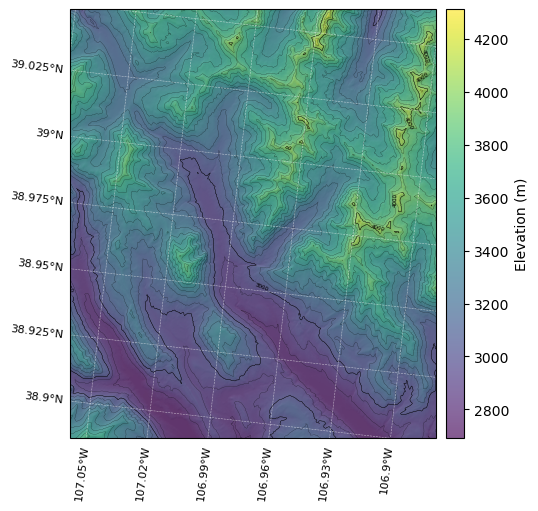

In [139]:
# quick plot of the DEM data
# - set 'contour=False' to remove contour lines
# - change contour line width with 'linewidths' arg
# - specify a colormap with 'cmap' arg
# - set 'grid=False' to remove gridlines and labels
# - set 'output='save'' to save the figure as a .png file (the 'dpi' arg adjusts resolution, default is 300)

terrainplot(terrain_data,contour=True,bounding_box=[-107.06,-106.9,38.9,39.05],linewidths=0.13,cmap=None,output='show',grid=True)

### **2. Calculate Terrain Stats**

The `cap_analysis()` function integrates several terrain calculations and returns an xarray.Dataset with CAP classifications using the following values:

`1` = CAP \
`0` = no signal \
`-1` = no CAP 

A copy of the xarray.Dataset is also saved to netcdf in `output/`.

DEM size, resolution, and number of iterations through distance values (i.e., the length of the array passed to `xv_dist`) all influence algorithm speed. The algorithm is quick to run over small scales at a reasonable resolution, but is not optimized for performance and may fail under system memory constraints for large or high resolution DEMs.

In [28]:
# run CAP analysis
# - cross-valley distance (xv_dist) = 2 * r r-radius (Lundquist et al, 2008). 
# - always pass a list to xv_dist, even if it contains only a single value: e.g. xv_dist=[2000]
# - to iterate over multiple cross-valley distances, pass an array of distances: e.g. xv_dist=[1000,2000,3000]
# - the resolution arg must match the resolution of the DEM file. The function does not check for this, so be sure to pass the correct value.
# - output is saved to file as a .nc file in the 'output/' directory. 

terrain_stats = cap_analysis(terrain_data=terrain_data, xv_dist=[4000,3000,2000])
# note: ZarrUserWarning messages are expected when saving the output file

Iterating through critical values...
a progress indicator will appear shortly

c:\Users\johnc\miniforge3\envs\ColdAirPooling\Lib\site-packages\zarr\api\asynchronous.py:244: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(



 processing xv_dist: 4000.0 ...
33.3% complete

c:\Users\johnc\miniforge3\envs\ColdAirPooling\Lib\site-packages\zarr\api\asynchronous.py:244: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(



 processing xv_dist: 3000.0 ...
66.7% complete

c:\Users\johnc\miniforge3\envs\ColdAirPooling\Lib\site-packages\zarr\api\asynchronous.py:244: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(



 processing xv_dist: 2000.0 ...
100.0% complete

c:\Users\johnc\miniforge3\envs\ColdAirPooling\Lib\site-packages\zarr\api\asynchronous.py:244: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


### **3. Plotting**

Below are a few crude plotting examples with xarray's built in `.plot()` function, as well as a custom function `plotcap()` to visualize local CAP classifications against local terrain. 

In [118]:
import xarray as xr
import matplotlib.pyplot as plt

First, open the saved zarr directory and reassign the crs from the spatial_ref variable.

In [39]:
ds = xr.open_zarr('output/CAP_layers.zarr')
crs = ds['spatial_ref'].attrs.get("crs_wkt")
ds = ds.rio.write_crs(crs)
ds

<xarray.Dataset> Size: 28MB
Dimensions:      (y: 815, x: 501, xv_dist: 3)
Coordinates:
    spatial_ref  int64 8B 0
  * x            (x) float64 4kB -9.465e+05 -9.465e+05 ... -9.339e+05 -9.339e+05
  * xv_dist      (xv_dist) float64 24B 4e+03 3e+03 2e+03
  * y            (y) float64 7kB 1.839e+06 1.839e+06 ... 1.816e+06 1.816e+06
Data variables:
    CAP          (y, x, xv_dist) float64 10MB dask.array<chunksize=(204, 251, 1), meta=np.ndarray>
    curvature    (y, x, xv_dist) float64 10MB dask.array<chunksize=(204, 251, 1), meta=np.ndarray>
    elevation    (y, x) float32 2MB dask.array<chunksize=(408, 251), meta=np.ndarray>
    rank         (y, x, xv_dist) float32 5MB dask.array<chunksize=(408, 251, 1), meta=np.ndarray>
    slope        (y, x) float32 2MB dask.array<chunksize=(408, 251), meta=np.ndarray>
Attributes:
    CAP Signal:  -1=no-CAP, 0=no-Signal, 1=CAP

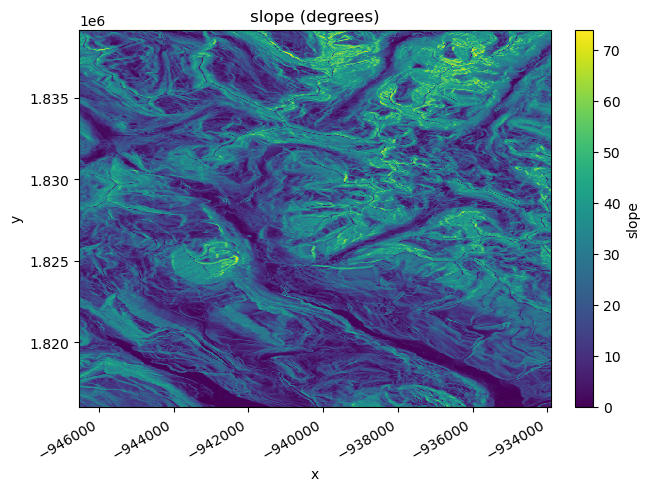

In [120]:
# plot slope
fig, ax = plt.subplots()

ds.sel(xv_dist=3000)['slope'].plot(cmap='viridis')
plt.title('slope (degrees)')
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.show()

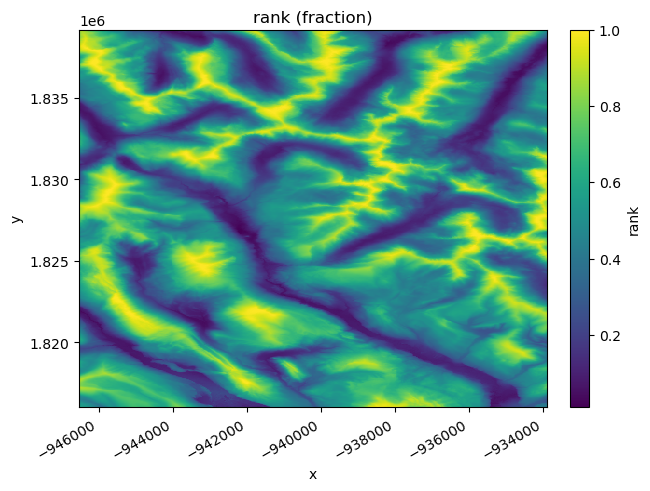

In [121]:
# plot slope
fig, ax = plt.subplots()

ds.sel(xv_dist=3000)['rank'].plot(cmap='viridis')
plt.title('rank (fraction)')
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.show()

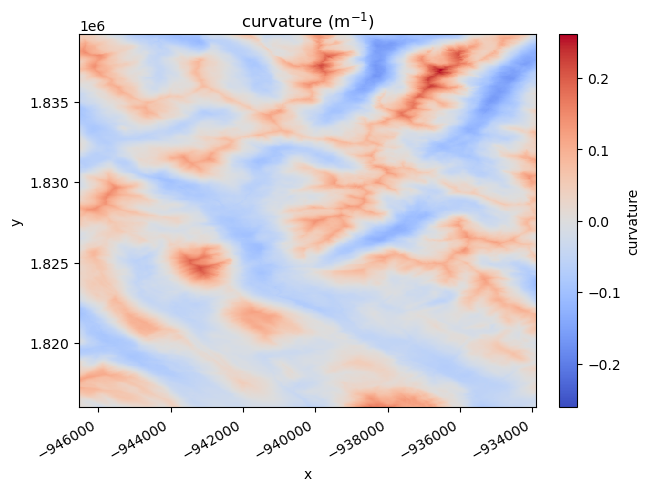

In [123]:
# plot curvature
fig, ax = plt.subplots()

ds.sel(xv_dist=3000)['curvature'].plot(cmap='coolwarm')
plt.title('curvature (m$^{-1}$)')
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.show()

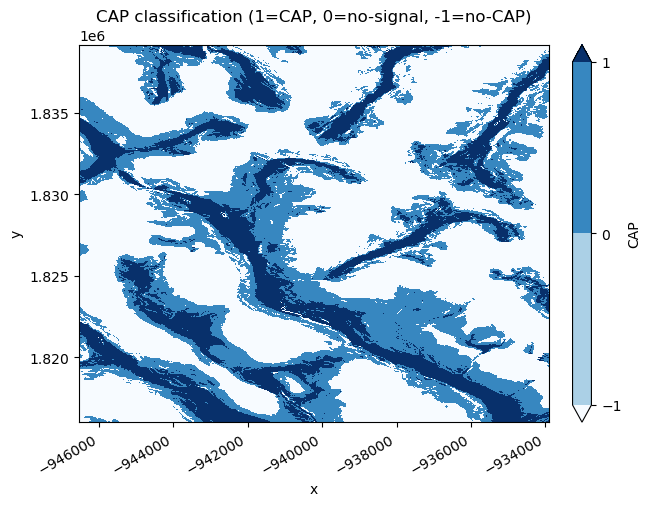

In [127]:
# plot CAP classifications
fig, ax = plt.subplots()

ds.sel(xv_dist=3000)['CAP'].plot(levels=[-.99999,0,.99999],cmap='Blues')
plt.title('CAP classification (1=CAP, 0=no-signal, -1=no-CAP)')
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.show()

The **plotcap** function is a custom plotting function to create some nice looking visualizations of CAP regions. It is best suited for local-scale plots, as statewide maps can be quite dense and plotting on larger scales may cause unexpected formatting problems. Paramaters can be further adjusted in the source code. 

**plotcap** is provided for illustrative purposes only. If you use or adapt figures generated by this code for publication, please attribute this repository.

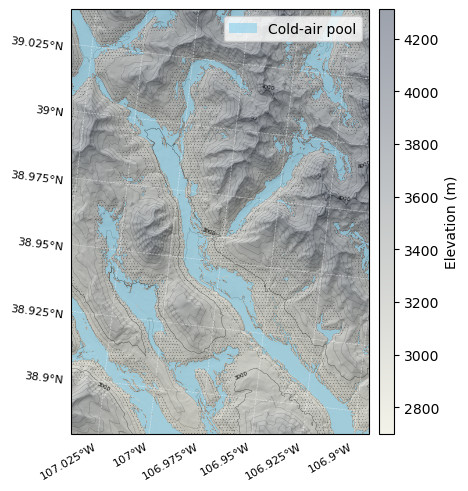

In [117]:
# plot CAP with terrain
# - enable 'shade=True' to shade region of no signal.
# - enable 'contour=True' to add contour lines to the elevation plot (automatically contours every 100m, with bold lines every 1000m).
# - disable 'grid=False' to remove gridlines and labels.
# - use the 'bounding_box' argument to specify the area to plot (use WGS84).
# - use the 'linewidths' argument to change the contour line width. Default is 0.05.
# - if output='save', use the 'dpi' argument to change the resolution of the saved figure. Default is 300.

plotcap(terrain_stats=ds,
        xv_dist=3000,
        bounding_box=[-107.04,-106.915,38.89,39.04],
        output='show', # change to 'save' to save figure as .png
        contour=True,
        shade=True,
        linewidths=0.07)

The optional `depth_plot` arg visualizes the density of CAP classifications across multiple cross-valley distances. For each consecutively smaller cross-valley distance, CAP is only shown where the previous (larger) iteration also classified CAP. The blue shading indicates the number of iterations which classified CAP at that pixel following this logic.

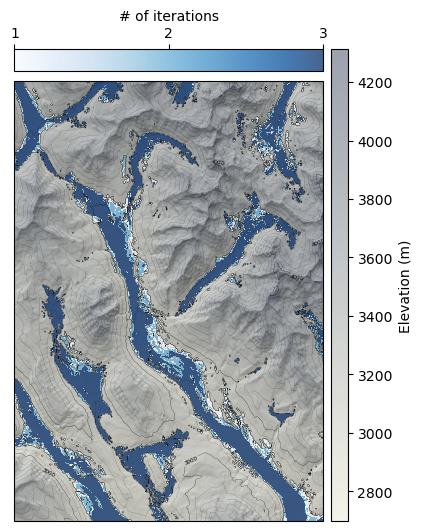

In [116]:
# example with depth_plot=True
# - note that 'depth_plot=True' is not compatible with 'shade=True'. It will not pass an error if both are enabled, but the shading will not appear.
# - if the colorbar is overlapping with the map, try changing the figsize, specifically figure width, in the source code --> fig, ax = plt.subplots(figsize=(_,_))

plotcap(terrain_stats=ds,
        xv_dist=3000,
        bounding_box=[-107.04,-106.915,38.89,39.04],
        output='show', # change to 'save' to save figure as .png
        depth_plot=True,
        contour=True,
        shade=False,
        grid=False,
        linewidths=0.07)

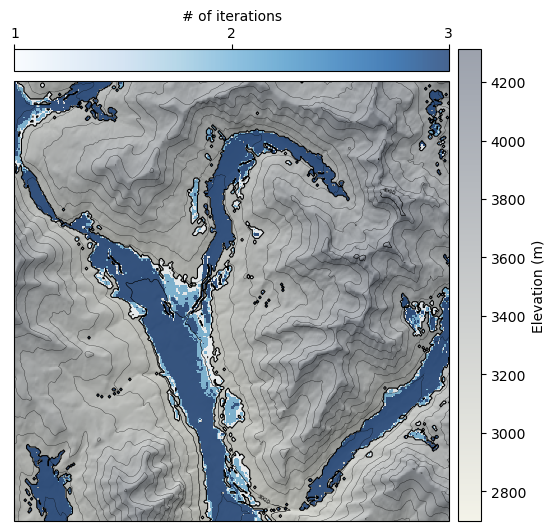

In [115]:
# same as above but with bounding box and larger linewidths

plotcap(terrain_stats=ds,
        xv_dist=3000,
        bounding_box=[-107.04,-106.95,38.96,39.03],
        depth_plot=True,
        contour=True,
        linewidths=0.2,
        grid=False,
        output='show')